In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import plotly.express as px

In [3]:
# 1. Load Data
df = pd.read_csv('student_data_extended.csv')
df = df.drop(columns=['Unnamed: 0'])
print("Dataset Loaded. Shape:", df.shape)
df.head()

Dataset Loaded. Shape: (1000, 2)


,ExtracurricularActivities,ClubMemberships
0,Debate Club,"Music Club, Art Club, Sports Team, Debate Club..."
1,Debate Club,"Art Club, Music Club, Sports Team, Coding Club"
2,Volunteer Group,"Music Club, Art Club, Debate Club, Volunteer G..."
3,Volunteer Group,"Sports Team, Volunteer Group"
4,Sports Team,"Sports Team, Volunteer Group, Music Club"


In [4]:
# Preprocessing: Clean strings and combine
df['Combined_Info'] = df['ExtracurricularActivities'].str.replace(' ', '_') + ' ' + \
                    df['ClubMemberships'].str.replace(', ', ' ').str.replace(' ', '_')

In [5]:
# Binary Vectorization works better for "tags" or "club names"
vectorizer = CountVectorizer(binary=True, token_pattern=r'\b\w+\b')
X_binary = vectorizer.fit_transform(df['Combined_Info'])

print(f"Feature matrix created with {X_binary.shape[1]} unique activity tags.")

Feature matrix created with 548 unique activity tags.


In [6]:
# Reduce dimensions to capture core student archetypes
svd = TruncatedSVD(n_components=min(10, X_binary.shape[1]-1), random_state=42)
X_svd = svd.fit_transform(X_binary)

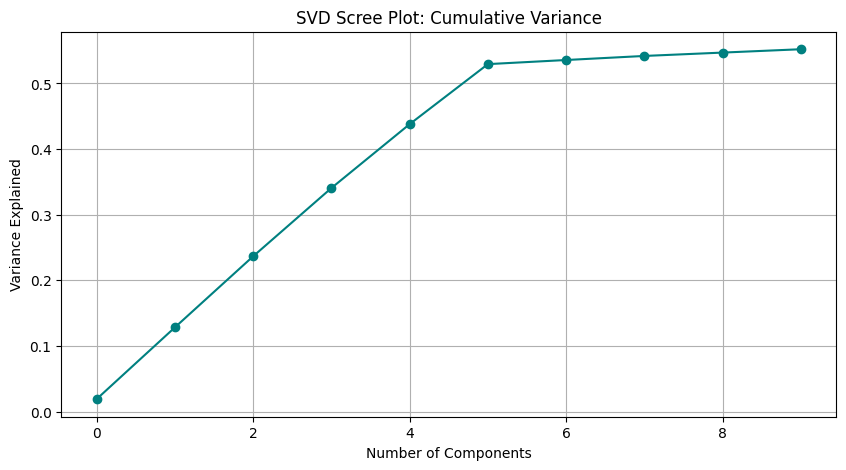

In [7]:
# Scree Plot to see the 'Good Value'
plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(svd.explained_variance_ratio_), marker='o', color='teal')
plt.title('SVD Scree Plot: Cumulative Variance')
plt.xlabel('Number of Components')
plt.ylabel('Variance Explained')
plt.grid(True)
plt.show()

In [8]:
def remove_noise(data_matrix, df_orig, n_comp=3):
    temp_df = pd.DataFrame(data_matrix[:, :n_comp], columns=[f'SVD_{i+1}' for i in range(n_comp)])
    
    Q1 = temp_df.quantile(0.05) # Aggressive cleaning
    Q3 = temp_df.quantile(0.95)
    IQR = Q3 - Q1
    
    mask = ((temp_df >= (Q1 - 1.5 * IQR)) & (temp_df <= (Q3 + 1.5 * IQR))).all(axis=1)
    return data_matrix[mask], df_orig[mask].copy()

X_clean, df_final = remove_noise(X_svd, df)
print(f"Cleaned Data Size: {len(df_final)} students remaining.")

Cleaned Data Size: 1000 students remaining.


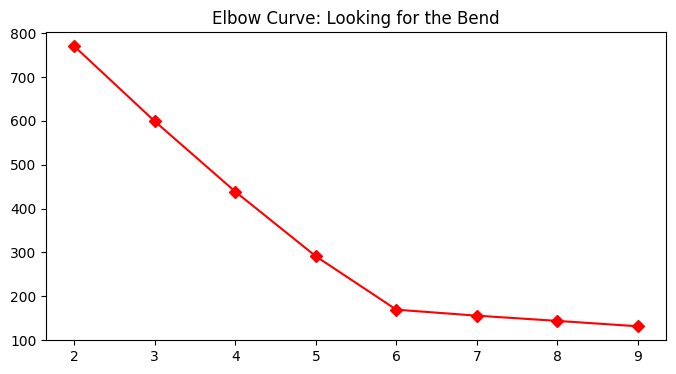

In [9]:
inertia = []
K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    km.fit(X_clean)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='D', color='red')
plt.title('Elbow Curve: Looking for the Bend')
plt.show()

In [10]:
# Based on the Elbow, let's pick K=4 for distinct archetypes
best_k = 6
model = KMeans(n_clusters=best_k, random_state=42, n_init=20)
df_final['Cluster'] = model.fit_predict(X_clean)

In [11]:
# Calculate Silhouette
score = silhouette_score(X_clean, df_final['Cluster'])
print(f"Improved Silhouette Score: {score:.4f}")

Improved Silhouette Score: 0.7336


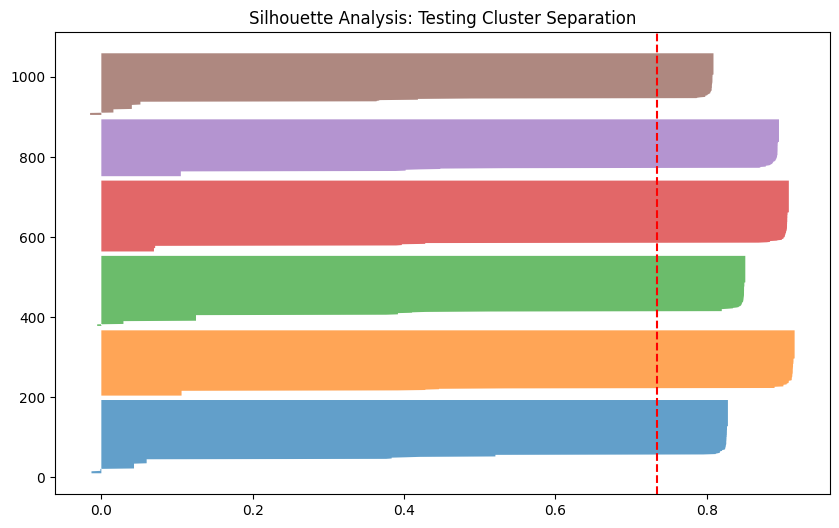

In [12]:
# Visualize the Silhouette 'Knives'
sample_silhouette_values = silhouette_samples(X_clean, df_final['Cluster'])
plt.figure(figsize=(10, 6))
y_lower = 10
for i in range(best_k):
    ith_cluster_v = sample_silhouette_values[df_final['Cluster'] == i]
    ith_cluster_v.sort()
    y_upper = y_lower + len(ith_cluster_v)
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_v, alpha=0.7)
    y_lower = y_upper + 10
plt.axvline(x=score, color="red", linestyle="--")
plt.title("Silhouette Analysis: Testing Cluster Separation")
plt.show()

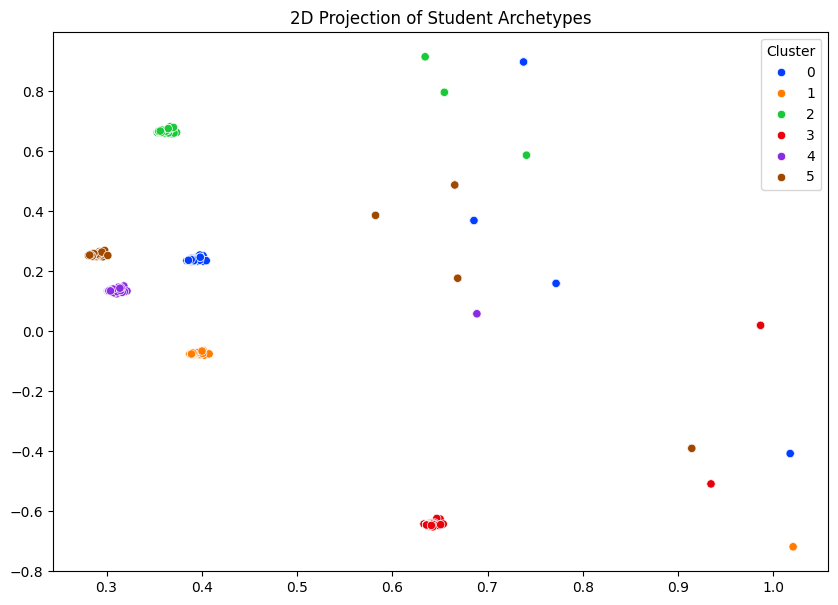

In [13]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_clean[:,0], y=X_clean[:,1], hue=df_final['Cluster'], palette='bright')
plt.title("2D Projection of Student Archetypes")
plt.show()

In [14]:
df_final['x'], df_final['y'], df_final['z'] = X_clean[:,0], X_clean[:,1], X_clean[:,2]

fig = px.scatter_3d(
    df_final, x='x', y='y', z='z', color='Cluster',
    hover_name='ExtracurricularActivities',
    hover_data=['ClubMemberships'],
    title="3D Student Interactive Clusters",
    color_discrete_sequence=px.colors.qualitative.Bold, # High contrast colors
    template="plotly_dark"
)
fig.show()

In [16]:
import pickle
open('activity_kmeans_model.pkl', 'wb') 


<_io.BufferedWriter name='activity_kmeans_model.pkl'>